## LangGraph - Building Agent Workflows

In [3]:
from langgraph.graph import StateGraph, END
from langchain_community.llms import Ollama
from typing import TypedDict, Annotated
import pandas as pd
!pip install graphviz 
from graphviz import Digraph
from IPython.display import display


  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)


In [4]:
# Define the state (data that agents share)
class GameState(TypedDict):
    raw_data: str
    summary: str

In [5]:
# Create sample poker game data
data = pd.DataFrame({
    "player": ["P1", "P2", "P3"],
    "action": ["bet 1000", "fold", "raise 5000"],
    "hand": ["Flush", "Pair", "Straight"]
})
data_path = "poker_logs.csv"
data.to_csv(data_path, index=False)

In [6]:
# Agent 1: Load and process data
def process_data(state: GameState) -> GameState:
    df = pd.read_csv(data_path)
    state["raw_data"] = df.to_string()
    return state

In [12]:
# Agent 2: Summarize data using Mistral
def summarize_data(state: GameState) -> GameState:
    llm = Ollama(model="llama3.2")
    prompt = f"Summarize this poker game data:\n{state['raw_data']}"
    state["summary"] = llm.invoke(prompt)
    return state

In [13]:
# Build the workflow
workflow = StateGraph(GameState)
workflow.add_node("process_data", process_data)
workflow.add_node("summarize_data", summarize_data)
workflow.add_edge("process_data", "summarize_data")
workflow.add_edge("summarize_data", END)
workflow.set_entry_point("process_data")

In [14]:
# Visualize LangGraph workflow
def visualize_workflow(workflow):
    dot = Digraph(comment="LangGraph Workflow")
    dot.attr(rankdir="LR")  # Left to right layout

    # Add nodes
    for node in workflow.nodes:
        dot.node(node, node)

    # Add entry point (safely access internal attribute)
    dot.node("START", "START", shape="circle")

    # Use protected member to get entry point (LangGraph stores it here)
    entry_point = workflow._entry_point if hasattr(workflow, "_entry_point") else list(workflow.nodes)[0]
    dot.edge("START", entry_point)

    # Add edges
    for edge in workflow.edges:
        dot.edge(edge[0], edge[1])

    # Add END node
    dot.node("END", "END", shape="doublecircle")
    return dot

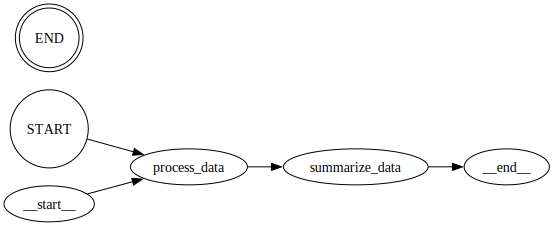

In [15]:
# Display the graph
graph = visualize_workflow(workflow)
display(graph)

In [17]:
# Run the workflow
app = workflow.compile()
result = app.invoke({"raw_data": "", "summary": ""})
print("LangGraph Result - Summary:", result["summary"])

LangGraph Result - Summary: Here's a summary of the poker game data:

- The game involves 3 players, P1, P2, and P3.
- In the first round, P1 bet 1000 chips and showed a Flush hand.
- In the second round, P2 folded, giving up their hand.
- In the third round, P3 raised 5000 chips and showed a Straight hand.

It appears to be a high-stakes game where P1 and P3 are engaged in a betting battle.


## Multi-Agent Project: Poker Game Analysis and Strategy System

In [21]:
# Import libraries
from langgraph.graph import StateGraph, END
#from crewai import Agent, Task, Crew
#from autogen import AssistantAgent, UserProxyAgent, config_list_from_json
from langchain_community.llms import Ollama
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
# from langchain.chains import RetrievalQA
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
from typing import TypedDict, Annotated
import PyPDF2